# Multimodal Product Search System

## Overview

This project demonstrates a multimodal AI pipeline for e-commerce product understanding and retrieval. The system combines computer vision, large language models, and vector search techniques to automatically analyze product images, generate descriptive metadata, and retrieve visually similar products.

## Features

* Automatic image caption generation using BLIP.
* E-commerce metadata generation using a Large Language Model (Qwen).
* Image feature extraction using Vision Transformer (ViT).
* High-performance similarity search using FAISS.
* Visual retrieval of related products based on image embeddings.

## Workflow

1. Load and preprocess product images.
2. Generate natural language captions from images.
3. Convert captions into structured product metadata.
4. Extract semantic image embeddings using ViT.
5. Store embeddings in a FAISS vector index.
6. Retrieve visually similar products for a given query image.

## Technologies Used

* Python
* Hugging Face Transformers
* BLIP
* Qwen 2.5
* Vision Transformer (ViT)
* FAISS
* PyTorch
* NumPy
* Matplotlib

## Applications

* E-commerce product search
* Product recommendation systems
* Visual similarity matching
* Automated catalog enrichment
* AI-powered retail solutions


In [1]:
!pip install -q transformers accelerate sentencepiece

In [2]:
!pip install --upgrade pip -q
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.2 MB/s eta 0:00:00


In [3]:
import faiss
print(faiss.__version__)

1.14.3


In [4]:
import torch
import pandas as pd
import numpy as np

from PIL import Image
from tqdm import tqdm

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    CLIPProcessor,
    CLIPModel,
    pipeline
)

import faiss

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [6]:
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [7]:
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [8]:
generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    device_map="auto"
)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
def generate_caption(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device)

    output = blip_model.generate(
        **inputs,
        max_new_tokens=40
    )

    caption = blip_processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption

In [10]:
def generate_metadata(caption):

    prompt = f"""
Convert this product description into ecommerce metadata.

Product:
{caption}

Output format:

Category:
Title:
Description:
Tags:
"""
    result = generator(
        prompt,
        max_new_tokens=150,
        do_sample=False,
        temperature=0.1
    )

    return result[0]["generated_text"]

In [11]:
image_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images/10005.jpg"

caption = generate_caption(image_path)

print("CAPTION:")
print(caption)

CAPTION:
a black and blue shirt with a white stripe


In [12]:
metadata = generate_metadata(caption)

print(metadata)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Convert this product description into ecommerce metadata.

Product:
a black and blue shirt with a white stripe

Output format:

Category:
Title:
Description:
Tags:
Color:
Size:
Price:
Availability:

Category: Clothing
Title: Black and Blue Stripe Shirt
Description: This stylish shirt features a bold black and blue color scheme with a striking white stripe down the center, perfect for adding a pop of color to any outfit.
Tags: black, blue, stripe, shirt
Color: Black, Blue
Size: S, M, L, XL, XXL
Price: $25.99
Availability: In Stock

Note: The size and price are placeholders as the actual values would need to be determined based on the specific product. The tags have been simplified to include only the main colors and the type of shirt. Adjustments may be needed based on the exact product details. Here's


In [13]:
fields = [
    "Category:",
    "Title:",
    "Description:",
    "Tags:",
    "Color:",
]

lines = metadata.split("\n")

clean_lines = []

for line in lines:
    if any(line.startswith(field) for field in fields):
        clean_lines.append(line)

print("\n".join(clean_lines))

Category:
Title:
Description:
Tags:
Color:
Category: Clothing
Title: Black and Blue Stripe Shirt
Description: This stylish shirt features a bold black and blue color scheme with a striking white stripe down the center, perfect for adding a pop of color to any outfit.
Tags: black, blue, stripe, shirt
Color: Black, Blue


In [14]:
import os

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

all_images = [
    os.path.join(image_dir, x)
    for x in os.listdir(image_dir)
][:100]

In [15]:
from transformers import AutoImageProcessor, AutoModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

vit_model = AutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k"
).to(device)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [16]:
from PIL import Image
import numpy as np

def get_image_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        outputs = vit_model(**inputs)

        embedding = outputs.pooler_output

    embedding = embedding.detach().cpu().numpy()

    embedding = embedding / np.linalg.norm(
        embedding,
        axis=1,
        keepdims=True
    )

    return embedding

In [17]:
emb = get_image_embedding(all_images[0])

print(type(emb))
print(emb.shape)

<class 'numpy.ndarray'>
(1, 768)


In [18]:
all_images = all_images[:50]

In [19]:
from tqdm import tqdm

embeddings = []

for img_path in tqdm(all_images):

    emb = get_image_embedding(img_path)

    embeddings.append(emb[0])

embeddings = np.array(embeddings)

print(embeddings.shape)

100%|██████████| 50/50 [00:16<00:00,  2.95it/s]

(50, 768)


In [20]:
import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(
    embeddings.astype("float32")
)

print(index.ntotal)

50


In [21]:
def search_similar_products(query_image, k=5):

    query_embedding = get_image_embedding(query_image)

    scores, indices = index.search(
        query_embedding.astype("float32"),
        k
    )

    return indices[0], scores[0]

/tmp/ipykernel_16/1368262814.py:37: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


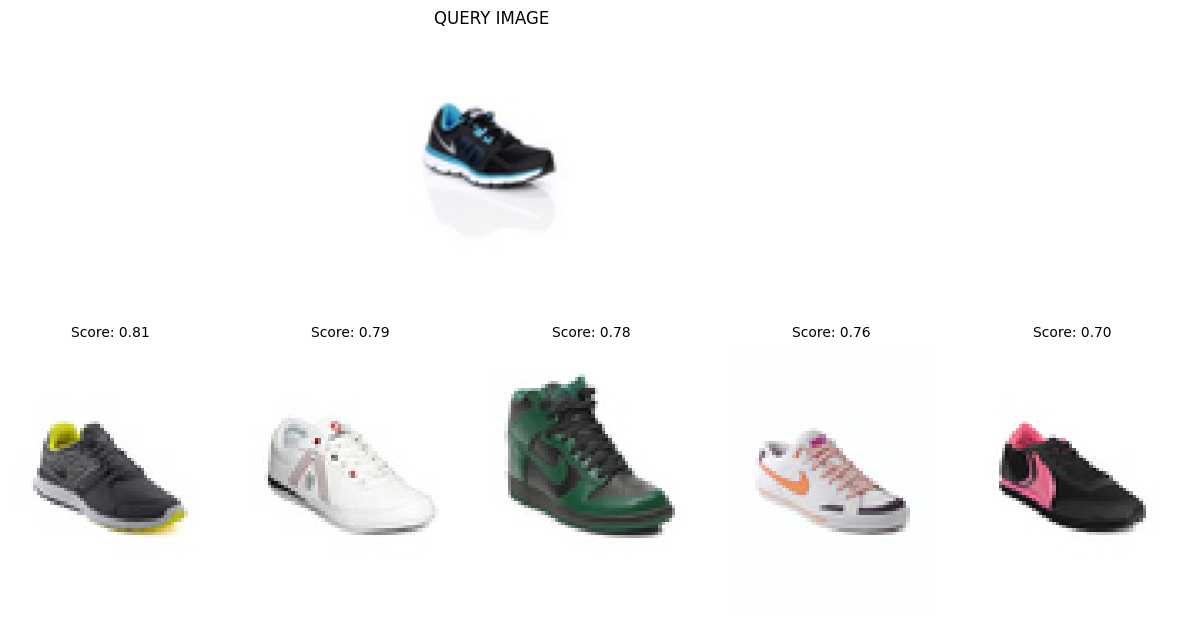

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

query_image = all_images[0]

indices, scores = search_similar_products(
    query_image,
    k=6
)

fig = plt.figure(figsize=(15,8))

# Query Image
plt.subplot(2, 6, 3)
img = Image.open(query_image)
plt.imshow(img)
plt.axis("off")
plt.title("QUERY IMAGE", fontsize=12)

# Similar Images
for i in range(1, len(indices)):

    idx = indices[i]

    plt.subplot(2, 5, i + 5)

    sim_img = Image.open(all_images[idx])

    plt.imshow(sim_img)
    plt.axis("off")

    plt.title(
        f"Score: {scores[i]:.2f}",
        fontsize=10
    )

plt.tight_layout()
plt.show()